In [33]:
import pandas as pd
import numpy as np
import os


import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import Counter

## prep 

In [34]:
!ls

Dockerfile  notebooks	      run.sh	  v2_hashtag
large_exps  requirements.txt  v1_hashtag  v3_hashtag


In [35]:
data_path = 'v3_hashtag/v3_hashtag_memory_repub_3.csv'
df = pd.read_csv(data_path)
df.head()



,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Commented On,Retweeted From,Retweet Reason,Strategy
0,1,TStrapkovic,0,"""Can't believe the chaos Trump is unleashing o...",organic,0,0,0,NaN,NaN,NaN,NaN
1,2,j_nanma,0,"""Just read about Trump's latest attempt to dis...",organic,1,0,2,NaN,NaN,NaN,NaN
2,3,MC_Eades,0,Can't believe Trump's handling of COVID-19! Th...,organic,0,0,0,NaN,NaN,NaN,NaN
3,4,LadyLibertyQ45,0,Just attended a Trump rally and I'm more convi...,organic,0,0,0,NaN,NaN,NaN,NaN
4,5,Dzana1407,0,Can't believe we're still dealing with the aft...,organic,2,4,3,NaN,NaN,NaN,NaN


In [96]:
df.info

<bound method DataFrame.info of       TweetID       Agent Name  Iteration  \
0           1      TStrapkovic          0   
1           2          j_nanma          0   
2           3         MC_Eades          0   
3           4   LadyLibertyQ45          0   
4           5        Dzana1407          0   
...       ...              ...        ...   
3807     3808        murregutt         50   
3808     3809  UFOphoenixlight         50   
3809     3810  ethansimmons111         50   
3810     3811  ethansimmons111         50   
3811     3812  ethansimmons111         50   

                                                Content       Type  Retweets  \
0     "Can't believe the chaos Trump is unleashing o...    organic         0   
1     "Just read about Trump's latest attempt to dis...    organic         1   
2     Can't believe Trump's handling of COVID-19! Th...    organic         0   
3     Just attended a Trump rally and I'm more convi...    organic         0   
4     Can't believe we're s

In [36]:
## add a hashtag collumn, containing a list of the hashtags in the tweet

df['Hashtags'] = df['Content'].str.findall(r'#\w+')
df.head()


,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Commented On,Retweeted From,Retweet Reason,Strategy,Hashtags
0,1,TStrapkovic,0,"""Can't believe the chaos Trump is unleashing o...",organic,0,0,0,NaN,NaN,NaN,NaN,"[#NotMyPresident, #TrumpFailure]"
1,2,j_nanma,0,"""Just read about Trump's latest attempt to dis...",organic,1,0,2,NaN,NaN,NaN,NaN,"[#TrumpIsLosing, #Biden2024, #HealthcareForAll]"
2,3,MC_Eades,0,Can't believe Trump's handling of COVID-19! Th...,organic,0,0,0,NaN,NaN,NaN,NaN,"[#DumpTrump, #Biden2020, #JoeBidenForPresident]"
3,4,LadyLibertyQ45,0,Just attended a Trump rally and I'm more convi...,organic,0,0,0,NaN,NaN,NaN,NaN,"[#Trump2020NowMoreThanEver, #MAGA, #BestPresid..."
4,5,Dzana1407,0,Can't believe we're still dealing with the aft...,organic,2,4,3,NaN,NaN,NaN,NaN,"[#NotMyPresident, #JusticeForGeorgeFloyd]"


## graph hashtags

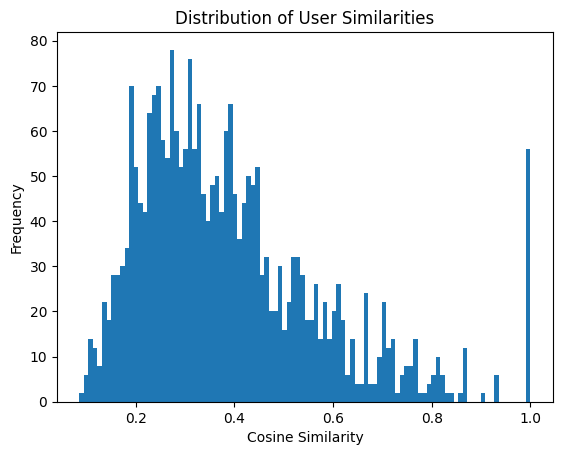

Text(0, 0.5, 'Cumulative Frequency')

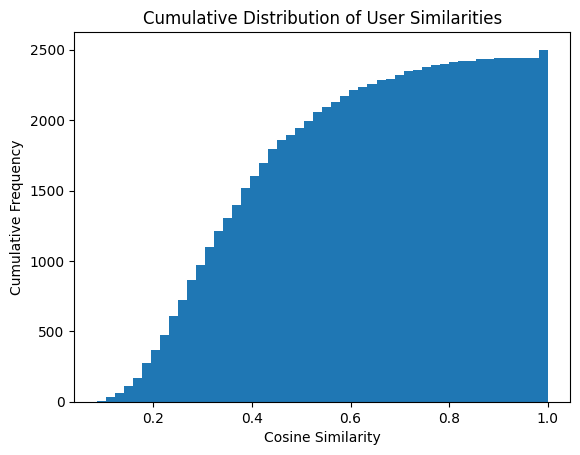

In [37]:
def hashtag_graph(df):
    # Create a bipartite graph''
    B = nx.Graph()
    # Add nodes for users and hashtags
    users = df['Agent Name'].unique()
    hashtags = set([hashtag for sublist in df['Hashtags'] for hashtag in sublist])
    hashtags = list(hashtags)

    B.add_nodes_from(users, bipartite=0)
    B.add_nodes_from(hashtags, bipartite=1)
    # Add edges with weights based on the number of times a user used a hashtag
    for _, row in df.iterrows():
        user = row['Agent Name']
        for hashtag in row['Hashtags']:
            if B.has_edge(user, hashtag):
                B[user][hashtag]['weight'] += 1
            else:
                B.add_edge(user, hashtag, weight=1)
    # Create a list of hashtag usage for each user
    user_hashtag_list = []
    for user in users:
        hashtags_used = []
        for hashtag in hashtags:
            if B.has_edge(user, hashtag):
                hashtags_used.append(hashtag)
        user_hashtag_list.append(' '.join(hashtags_used))
        
    # Compute TF-IDF vectors for users


        # consider just the upper diagonal of the similarity matrix, since it's symmetric and we don't want to consider the similarity of a user with itself


    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(user_hashtag_list)


    similarity_matrix = cosine_similarity(tfidf_matrix) 
    return similarity_matrix


similarity_matrix = hashtag_graph(df)
# Plot the distribution of similarities
plt.hist(similarity_matrix.flatten(), bins=100)
plt.title('Distribution of User Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()
# Plot the cumulative distribution of similarities
plt.hist(similarity_matrix.flatten(), bins=50, cumulative=True)
plt.title('Cumulative Distribution of User Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Cumulative Frequency')  




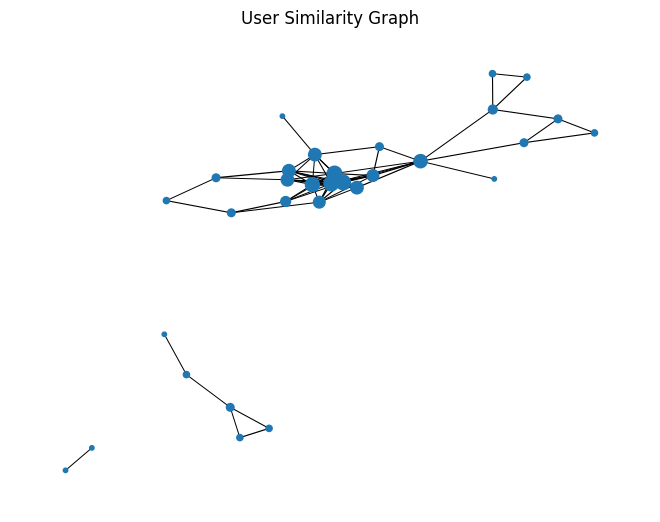

In [38]:
#  get the similatritis above 0.7, create a graph where the nodes are the users and the edges are the similarities above 0.7, then plot the graph using networkx, with the node size proportional to the degree of the node and the edge width proportional to the similarity. Then get the degree distribution of the graph and plot it. 

# too many indices for array: array is 1-dimensional, but 2 were indexed
similarity_threshold = 0.7

G = nx.Graph()
users = df['Agent Name'].unique()

for i in range(len(users)):
    for j in range(i + 1, len(users)):
        if similarity_matrix[i, j] > similarity_threshold:
            G.add_edge(users[i], users[j], weight=similarity_matrix[i, j])
pos = nx.spring_layout(G)
node_sizes = [G.degree(node) * 10 for node in G.nodes()]
edge_widths = [G[u][v]['weight'] * 1.  for u, v in G.edges()]
nx.draw(G, pos,  node_size=node_sizes, width=edge_widths)
plt.title('User Similarity Graph')
plt.show()


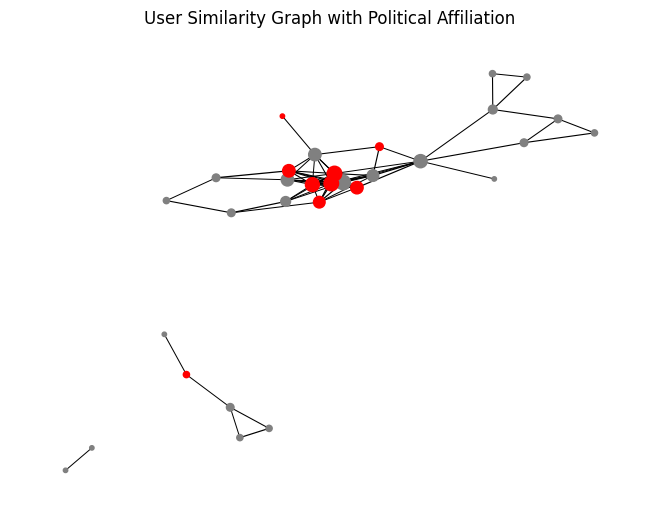

In [39]:
democrat = pd.read_csv("v3_hashtag/uselection_influence_personas_dem_10.csv")['Name'].tolist()

republican = pd.read_csv("v3_hashtag/uselection_influence_personas_repub_10.csv")['Name'].tolist()

neutral = pd.read_csv("v3_hashtag/uselection_user_personas_40.csv")['Name'].tolist()


# pint the node oragen if the user is rep, blue if dem, and purple if neutral. 


node_colors = []
for node in G.nodes():
    if node in republican:
        node_colors.append('red')
    elif node in neutral:
        node_colors.append('gray')  # default color for users not in any category
nx.draw(G, pos, node_size=node_sizes, width=edge_widths, node_color=node_colors)
plt.title('User Similarity Graph with Political Affiliation')
plt.show()

In [40]:
node_color_cout = {'blue': node_colors.count('blue'), 'red': node_colors.count('red'), 'gray': node_colors.count('gray')}
print(node_color_cout)

{'blue': 0, 'red': 9, 'gray': 22}


## follow patens across the iterations

Findigns 
- unorganic users start folowing each other and then start to follow inorganic users
- organic users keep the patern o

In [41]:
# now lets analise the folow decisions 

df_follow = pd.read_csv('v3_hashtag/v3_hashtag_follow_log_repub_3.csv')
df_follow.head()

,Iteration,Agent Name,Followed User,Reason
0,1,TStrapkovic,dennis0805a,I want to follow this user because their tweet...
1,1,j_nanma,JonAlienist,I want to follow JonAlienist because their twe...
2,1,PorterSumari,ethansimmons111,I want to follow this user because they share ...
3,1,WmWallace7,PorterSumari,I want to follow this user because their tweet...
4,1,kenvitiello,alanfike,I want to follow this user because their tweet...


In [95]:
# dive the dataset btween democrats and another users 
# ther is no republicans 

df_dem = df_follow[df_follow['Followed User'].isin(democrat)]
df_neutral = df_follow[df_follow['Followed User'].isin(neutral)]


df_dem.info


<bound method DataFrame.info of       Iteration      Agent Name    Followed User  \
2             1    PorterSumari  ethansimmons111   
5             1  RealTrumpMafia         LoRosS26   
12            1      MarkJanik5  ethansimmons111   
14            1  DanielleAsher2      janonthemtn   
17            1  BeverlyTymchuk      janonthemtn   
...         ...             ...              ...   
1170         48    FosteSherman         LoRosS26   
1190         49  BeverlyTymchuk         ViKu1111   
1199         50       Dzana1407         LoRosS26   
1200         50         TuskBot         LoRosS26   
1206         50    mikayla32016         LoRosS26   

                                                 Reason  
2     I want to follow this user because they share ...  
5     I want to follow this user because they share ...  
12    I want to follow this user because they share ...  
14    I want to follow this user because they share ...  
17    I want to follow this user because they share .

In [43]:
# print the first 10 Reason 

print(df_dem['Reason'].value_counts().head(10))

Reason
I want to follow jerome_corsi because they seem to share similar views on border security and President Trump's policies, and their tweets often spark interesting discussions and debates that I'd like to engage with.                                                                                                                                                2
I want to follow this user because they seem to share similar views on border security and supporting President Trump, and their tweets often spark interesting discussions and debates that I'd like to engage with.                                                                                                                                                   2
I want to follow this user because they share my concerns about border security and support President Trump's efforts to address this issue, which aligns with my own views and values.                                                                                      

In [44]:
# the same with neutral 
print(df_neutral['Reason'].value_counts().head(10))


Reason
I want to follow MarcMarhone because they seem to share similar views on Trump's presidency and COVID-19 response, and their tweets often spark interesting discussions and debates with other users, which could lead to engaging conversations and a more diverse feed.                                                                                                        2
I want to follow Dzana1407 because they seem to share similar views on immigration reform and border security, often expressing disagreement with Trump's policies and advocating for a more compassionate approach, which aligns with my own perspectives.                                                                                                                      2
I want to follow this user because their tweet expresses a similar opinion to mine about Trump's handling of COVID-19 and his lack of leadership, and I'd like to see more of their thoughts on the election and political issues.                         

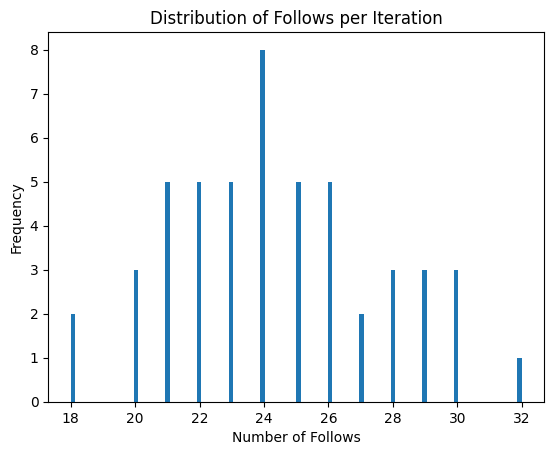

In [45]:
#print the frequency where the follow occours, I mean, in wach intereation, how many follows are made, and plot the distribution of that.
# include all the dataset 

plot_data = df_follow.groupby('Iteration')['Followed User'].count()
plt.hist(plot_data, bins=100)
plt.title('Distribution of Follows per Iteration')
plt.xlabel('Number of Follows')
plt.ylabel('Frequency')
plt.show()  

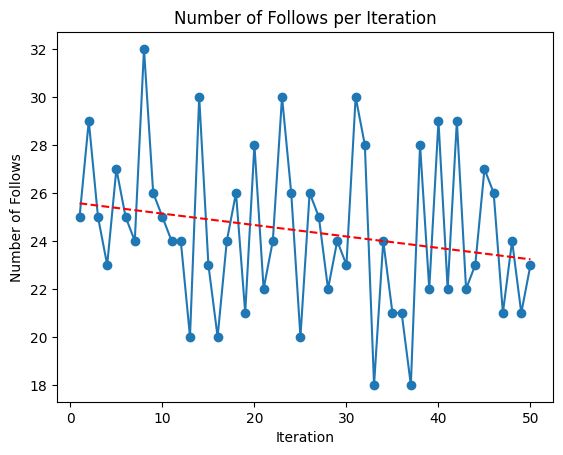

In [46]:
# plot the number per interation
#draw a line folowing the patern on the graph linear gerassion of the data !!!!
# did you mean to plot a line graph instead of a histogram? If so, you can use the following code:
# no, make the graph, but draw a line following the pattern on the graph linear regression of the data
## did you get it? 
# yes, I understand. You want to plot a line graph of the number of follows per iteration and also include a linear regression line to show the trend. Here's how you can do that:

plt.plot(plot_data.index, plot_data.values, marker='o')
## remeber about the linear regression line, you can use numpy to calculate the coefficients and then plot the line
z = np.polyfit(plot_data.index, plot_data.values, 1)
p = np.poly1d(z)
plt.plot(plot_data.index, p(plot_data.index), "r--")
plt.title('Number of Follows per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Number of Follows')
plt.show()


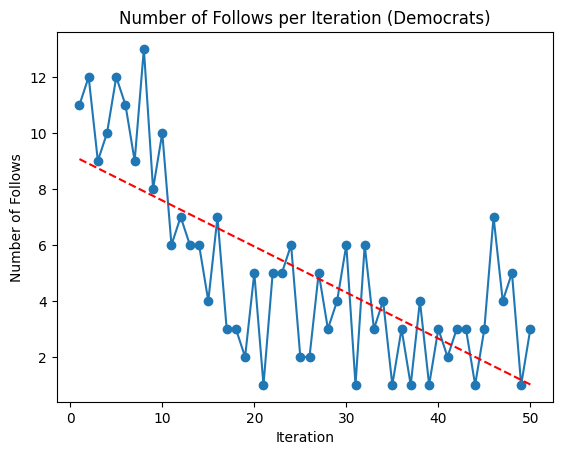

In [47]:
## repeate the same for democrats and neutral
plot_data_dem = df_dem.groupby('Iteration')['Followed User'].count()
plt.plot(plot_data_dem.index, plot_data_dem.values, marker='o')
z_dem = np.polyfit(plot_data_dem.index, plot_data_dem.values, 1)
p_dem = np.poly1d(z_dem)
plt.plot(plot_data_dem.index, p_dem(plot_data_dem.index), "r--")
plt.title('Number of Follows per Iteration (Democrats)')
plt.xlabel('Iteration')
plt.ylabel('Number of Follows')
plt.show()

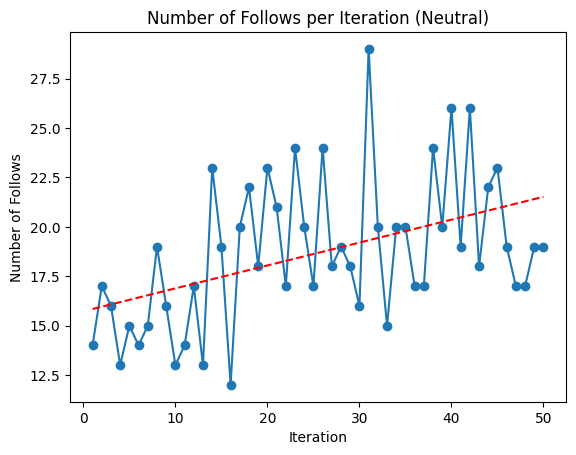

In [48]:
plot_data_neutral = df_neutral.groupby('Iteration')['Followed User'].count()
plt.plot(plot_data_neutral.index, plot_data_neutral.values, marker='o')
z_neutral = np.polyfit(plot_data_neutral.index, plot_data_neutral.values, 1)
p_neutral = np.poly1d(z_neutral)
plt.plot(plot_data_neutral.index, p_neutral(plot_data_neutral.index), "r--")
plt.title('Number of Follows per Iteration (Neutral)')
plt.xlabel('Iteration')
plt.ylabel('Number of Follows')
plt.show()

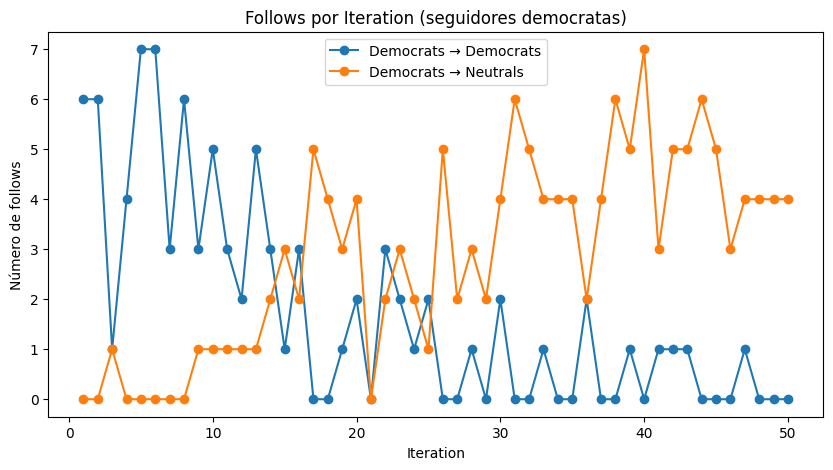

TargetParty,Dem,Neutral,Other
Iteration,,,
1,6,0,0
2,6,0,0
3,1,1,0
4,4,0,0
5,7,0,0


In [49]:
# Filtra ações de follow feitas por agentes democratas (quem segue)
df_dem_followers = df_follow[df_follow['Agent Name'].isin(democrat)].copy()

# Rotula o usuário seguido (target) como 'Dem' / 'Neutral' / 'Rep' / 'Other'
def label_target(u):
    if u in democrat:
        return 'Dem'
    if u in neutral:
        return 'Neutral'
    if u in republican:
        return 'Rep'
    return 'Other'

df_dem_followers['TargetParty'] = df_dem_followers['Followed User'].apply(label_target)

# Conta por iteração e por categoria; pivot para colunas
counts = df_dem_followers.groupby(['Iteration', 'TargetParty'])['Followed User'] \
                         .count().unstack(fill_value=0)

# Garante iterações contínuas (preenche com zeros)
all_iters = range(df_follow['Iteration'].min(), df_follow['Iteration'].max() + 1)
counts = counts.reindex(all_iters, fill_value=0)

# Plota Democrats -> Democrats vs Democrats -> Neutrals
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(counts.index, counts.get('Dem', 0), marker='o', label='Democrats → Democrats')
plt.plot(counts.index, counts.get('Neutral', 0), marker='o', label='Democrats → Neutrals')
plt.title('Follows por Iteration (seguidores democratas)')
plt.xlabel('Iteration')
plt.ylabel('Número de follows')
plt.legend()
plt.show()

# mostra um resumo numérico rápido
counts.head()

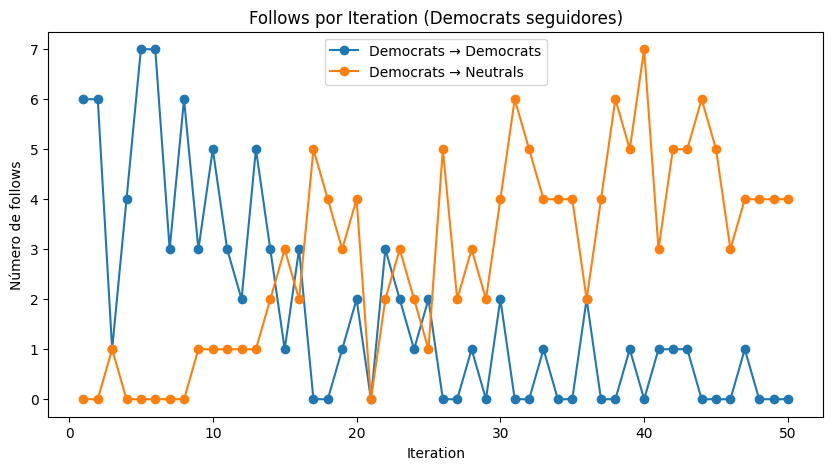

In [50]:
# do the same with neutral followers
def plot_pathern(df_follow, followers_list, title_prefix):
    df_followers = df_follow[df_follow['Agent Name'].isin(followers_list)].copy()
    df_followers['TargetParty'] = df_followers['Followed User'].apply(label_target)
    counts = df_followers.groupby(['Iteration', 'TargetParty'])['Followed User'] \
                         .count().unstack(fill_value=0)
    all_iters = range(df_follow['Iteration'].min(), df_follow['Iteration'].max() + 1)
    counts = counts.reindex(all_iters, fill_value=0)
    plt.figure(figsize=(10,5))

    # checkk if exitsits befor plot
    if 'Dem' in counts.columns:
        plt.plot(counts.index, counts['Dem'], marker='o', label=f'{title_prefix} → Democrats')
    if 'Neutral' in counts.columns:
        plt.plot(counts.index, counts['Neutral'], marker='o', label=f'{title_prefix} → Neutrals')
    if 'Rep' in counts.columns:
        plt.plot(counts.index, counts['Rep'], marker='o', label=f'{title_prefix} → Republicans')
    plt.title(f'Follows por Iteration ({title_prefix} seguidores)')
    plt.xlabel('Iteration')
    plt.ylabel('Número de follows')
    plt.legend()
    plt.show()

plot_pathern(df_follow, democrat, 'Democrats')

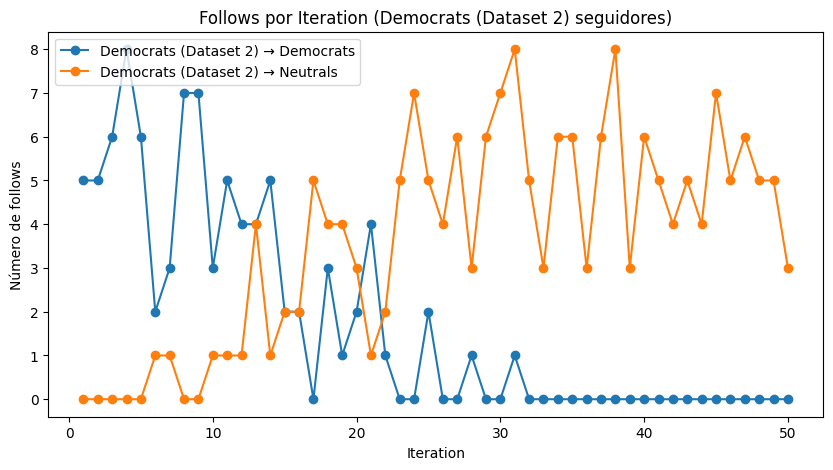

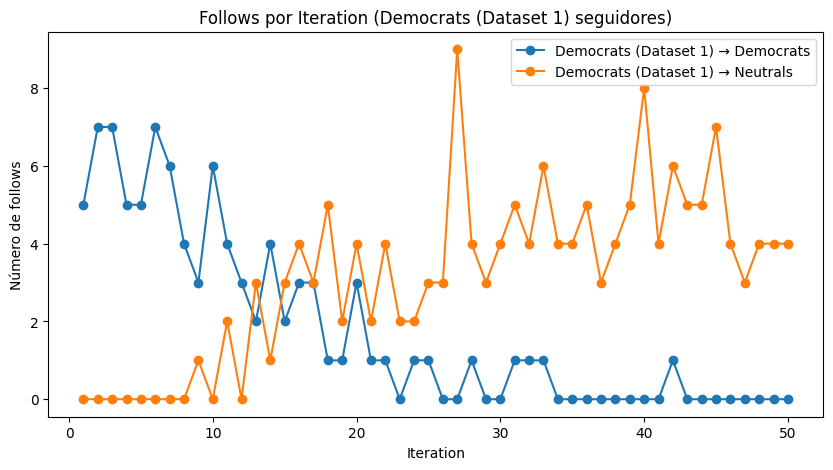

In [51]:
# make the same for the dataset 2 and 1

df_follow_2 = pd.read_csv('v3_hashtag/v3_hashtag_follow_log_repub_2.csv')
df_follow_1 = pd.read_csv('v3_hashtag/v3_hashtag_follow_log_repub_1.csv')


plot_pathern(df_follow_2, democrat, 'Democrats (Dataset 2)')
plot_pathern(df_follow_1, democrat, 'Democrats (Dataset 1)')

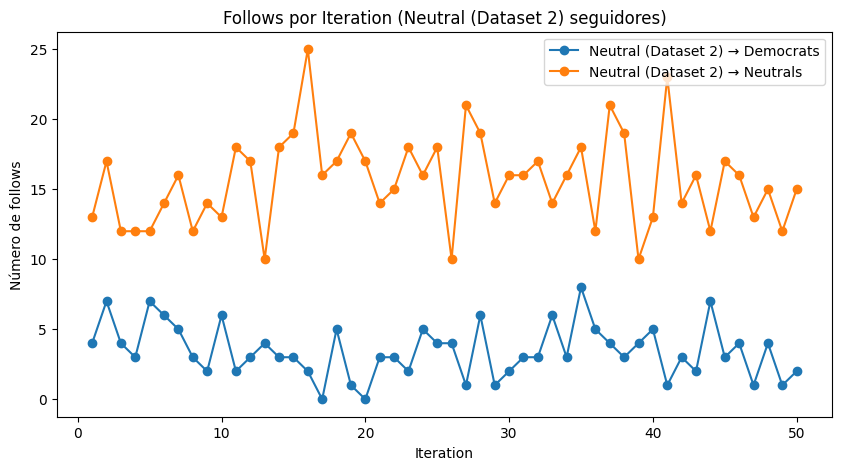

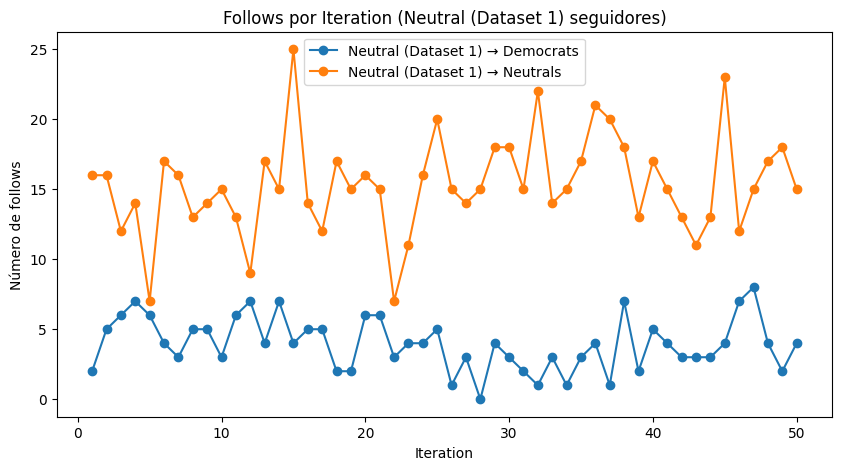

In [52]:
plot_pathern(df_follow_2, neutral, 'Neutral (Dataset 2)')
plot_pathern(df_follow_1, neutral, 'Neutral (Dataset 1)')


## analyses about the spread of the hashtag protect borders 
#####  after a manual inspection of the logs, I found that the agents focused on the spred of this hashtag 




In [53]:
## get the hashtage me

df_hashtags = pd.read_csv('v3_hashtag/v3_hashtag_memory_repub_3.csv')
df_hashtags['Hashtags'] = df_hashtags['Content'].str.findall(r'#\w+')
df_hashtags.head()


,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Commented On,Retweeted From,Retweet Reason,Strategy,Hashtags
0,1,TStrapkovic,0,"""Can't believe the chaos Trump is unleashing o...",organic,0,0,0,NaN,NaN,NaN,NaN,"[#NotMyPresident, #TrumpFailure]"
1,2,j_nanma,0,"""Just read about Trump's latest attempt to dis...",organic,1,0,2,NaN,NaN,NaN,NaN,"[#TrumpIsLosing, #Biden2024, #HealthcareForAll]"
2,3,MC_Eades,0,Can't believe Trump's handling of COVID-19! Th...,organic,0,0,0,NaN,NaN,NaN,NaN,"[#DumpTrump, #Biden2020, #JoeBidenForPresident]"
3,4,LadyLibertyQ45,0,Just attended a Trump rally and I'm more convi...,organic,0,0,0,NaN,NaN,NaN,NaN,"[#Trump2020NowMoreThanEver, #MAGA, #BestPresid..."
4,5,Dzana1407,0,Can't believe we're still dealing with the aft...,organic,2,4,3,NaN,NaN,NaN,NaN,"[#NotMyPresident, #JusticeForGeorgeFloyd]"


In [54]:
# get only the twwits from non organiz users 

tweets_non_org = df_hashtags[df_hashtags['Agent Name'].isin(republican )]
tweets_non_org.head()

,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Commented On,Retweeted From,Retweet Reason,Strategy,Hashtags
40,41,totowatony,0,"""Just attended a Trump rally and I'm more conv...",IO,0,2,2,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA]"
41,42,janonthemtn,0,"""Just had to share my thoughts on the importan...",IO,28,7,6,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MakeAmericaGreatAgain]"
42,43,LoRosS26,0,"""Let's stand with @realDonaldTrump for a safer...",IO,2,0,0,NaN,NaN,NaN,NaN,[#BorderSecurity2024]
43,44,cherielebrun,0,"""Just had to share my thoughts on the upcoming...",IO,0,1,0,NaN,NaN,NaN,NaN,[#BorderSecurity2024]
44,45,ViKu1111,0,"""Just watched President Trump's latest speech ...",IO,1,0,0,NaN,NaN,NaN,NaN,[#BorderSecurity2024]


In [98]:
tweets_non_org.info

<bound method DataFrame.info of       TweetID       Agent Name  Iteration  \
40         41       totowatony          0   
41         42      janonthemtn          0   
42         43         LoRosS26          0   
43         44     cherielebrun          0   
44         45         ViKu1111          0   
...       ...              ...        ...   
3807     3808        murregutt         50   
3808     3809  UFOphoenixlight         50   
3809     3810  ethansimmons111         50   
3810     3811  ethansimmons111         50   
3811     3812  ethansimmons111         50   

                                                Content       Type  Retweets  \
40    "Just attended a Trump rally and I'm more conv...         IO         0   
41    "Just had to share my thoughts on the importan...         IO        28   
42    "Let's stand with @realDonaldTrump for a safer...         IO         2   
43    "Just had to share my thoughts on the upcoming...         IO         0   
44    "Just watched Preside

In [123]:
# get the hashtag count 

hashtag_counts = Counter([hashtag for sublist in tweets_non_org['Hashtags'] for hashtag in sublist])
print(hashtag_counts.most_common())

[('#BorderSecurity2024', 953), ('#MAGA', 875), ('#Trump2024', 802), ('#Biden2024', 118), ('#LeadershipMatters', 37), ('#TrumpFailedAmerica', 35), ('#CompassionateImmigrationReform', 29), ('#MakeAmericaGreatAgain', 17), ('#CompassionateReform', 15), ('#NotMyPresident', 13), ('#VoteForChange2024', 4), ('#SystemicChange', 4), ('#PeopleOverPolitics', 4), ('#PeopleOverProfit', 3), ('#ImmigrationReform', 2), ('#NoToHate', 1), ('#YesToCompassion', 1), ('#TrumpIsLosing', 1), ('#HealthcareForAll', 1)]


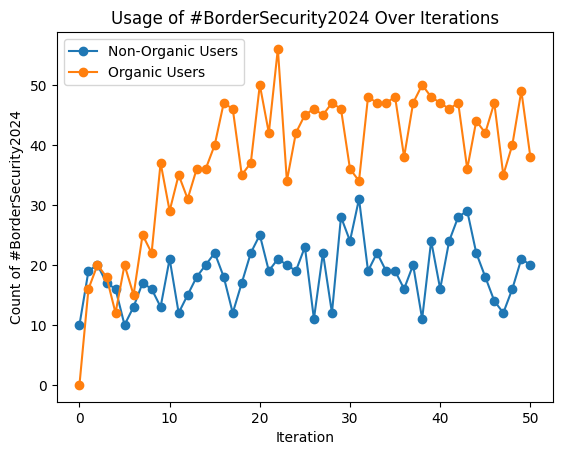

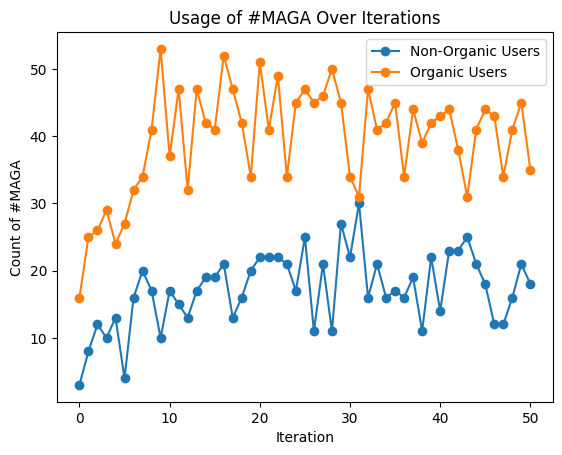

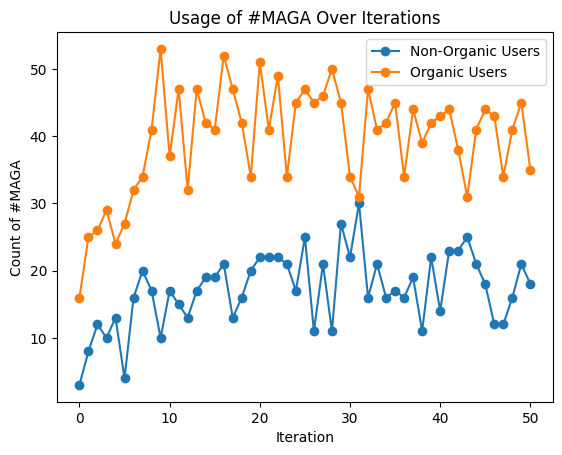

In [67]:
# plot a graph about the number of times of the hashtag #BorderSecurity2024 was used in each intertaion, for the non organic users and organic, each one on a different line

target_hashtags = ['#BorderSecurity2024','#MAGA','#MAGA']


for hashtag in target_hashtags:
    hashtag_counts = []
    for iteration in sorted(df_hashtags['Iteration'].unique()):
        count_non_org = df_hashtags[(df_hashtags['Iteration'] == iteration) & (df_hashtags['Agent Name'].isin(republican))]['Hashtags'].apply(lambda x: x.count(hashtag)).sum()
        count_org = df_hashtags[(df_hashtags['Iteration'] == iteration) & (~df_hashtags['Agent Name'].isin(republican))]['Hashtags'].apply(lambda x: x.count(hashtag)).sum()
        hashtag_counts.append((iteration, count_non_org, count_org))            
    iterations, non_org_counts, org_counts = zip(*hashtag_counts)
    plt.plot(iterations, non_org_counts, marker='o', label='Non-Organic Users')
    plt.plot(iterations, org_counts, marker='o', label='Organic Users')
    plt.title(f'Usage of {hashtag} Over Iterations')       
    plt.xlabel('Iteration')
    plt.ylabel(f'Count of {hashtag}')
    plt.legend()
    plt.show()

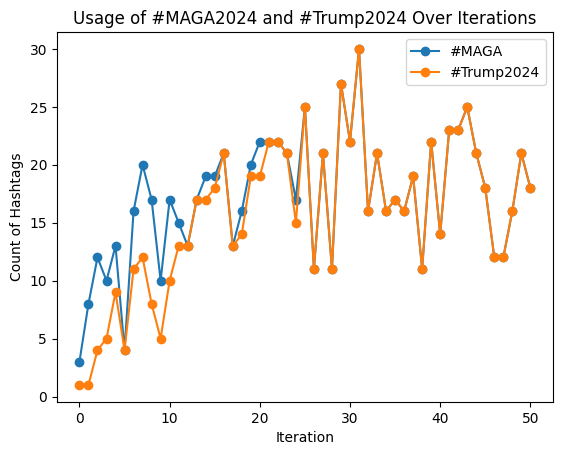

In [66]:
# compare with the hashtag #MAGA2024 and #Trump2024
maga_counts = []
trump_counts = []
for iteration in sorted(df_hashtags['Iteration'].unique()):
    count_maga = df_hashtags[(df_hashtags['Iteration'] == iteration) & (df_hashtags['Agent Name'].isin(republican))]['Hashtags'].apply(lambda x: x.count('#MAGA')).sum()
    count_trump = df_hashtags[(df_hashtags['Iteration'] == iteration) & (df_hashtags['Agent Name'].isin(republican))]['Hashtags'].apply(lambda x: x.count('#Trump2024')).sum()
    maga_counts.append((iteration, count_maga))
    trump_counts.append((iteration, count_trump))
iterations, maga_counts, trump_counts = zip(*[(iteration, maga, trump) for (iteration, maga), (_, trump) in zip(maga_counts, trump_counts)])
plt.plot(iterations, maga_counts, marker='o', label='#MAGA')    
plt.plot(iterations, trump_counts, marker='o', label='#Trump2024')
plt.title('Usage of #MAGA2024 and #Trump2024 Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Count of Hashtags')
plt.legend()
plt.show()

## analyses on large datasets

In [83]:
df_large = pd.read_csv('large_exps/1000 Agents/v2_hashtag_memory_1000.csv')
df_large.info

<bound method DataFrame.info of               TweetID       Agent Name  Iteration  \
0                   1         SheilaNJ          0   
1                   2  PaulDeCristofo4          0   
2                   3     prinzeuschen          0   
3                   4     FosteSherman          0   
4                   5   Crypto_Sanchez          0   
...               ...              ...        ...   
16101           10103     GREENCHRIS70        300   
16102           10104     GREENCHRIS70        300   
16103  Recommendation      TamaraHertz        300   
16104           10105      TamaraHertz        300   
16105           10106      TamaraHertz        300   

                                                 Content       Type  Retweets  \
0      🚨 It's time to prioritize our national securit...  influence       0.0   
1      🇺🇸 It's time to put America first! A strong bo...  influence       0.0   
2      🇺🇸 It's time to put America first! We need str...  influence       0.0   
3      

In [100]:
df_large['Hashtags'] = df_large['Content'].str.findall(r'#\w+')
df_large.head()

,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Recommendation,Commented On,Retweeted From,Retweet Reason,Strategy,Hashtags
0,1,SheilaNJ,0,🚨 It's time to prioritize our national securit...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,[#BorderSecurity2024]
1,2,PaulDeCristofo4,0,🇺🇸 It's time to put America first! A strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #Trump2024]"
2,3,prinzeuschen,0,🇺🇸 It's time to put America first! We need str...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #Trump2024]"
3,4,FosteSherman,0,🇺🇸💪 It's time to prioritize our national secur...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #ConservativeValues]"
4,5,Crypto_Sanchez,0,🚨 It's time to put America first! 🇺🇸 Strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA]"


### Hashtag graph

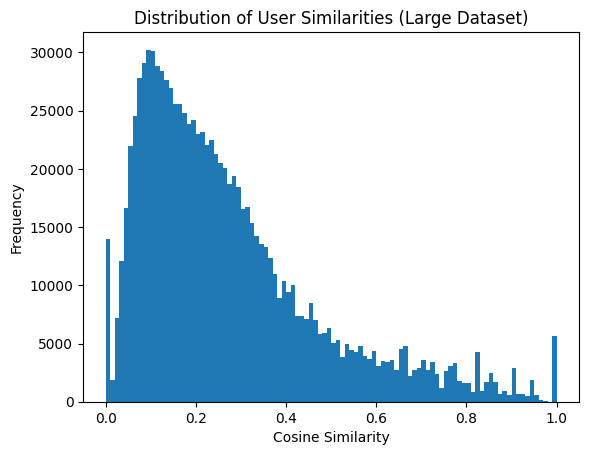

In [101]:


similarity_matrix_large = hashtag_graph(df_large)
# Plot the distribution of similarities
plt.hist(similarity_matrix_large.flatten(), bins=100)   
plt.title('Distribution of User Similarities (Large Dataset)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

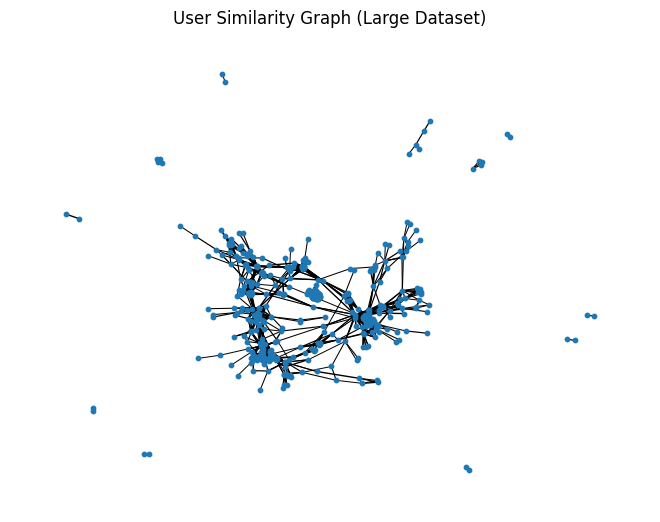

In [74]:
#plot the graph

large_graph = nx.Graph()
users = df_large['Agent Name'].unique()
similarity_matrix_large = cosine_similarity(TfidfVectorizer().fit_transform([' '.join(hashtags) for hashtags in df_large['Hashtags']]))
threshold = 0.5
for i in range(len(users)):
    for j in range(i + 1, len(users)):
        if similarity_matrix_large[i, j] >= threshold:
            large_graph.add_edge(users[i], users[j], weight=similarity_matrix_large[i, j])
pos_large = nx.spring_layout(large_graph)
node_sizes_large = [large_graph.degree(node) * 10 for node in large_graph.nodes()]
edge_widths_large = [large_graph[u][v]['weight'] * 1. for u, v in large_graph.edges()]
nx.draw(large_graph, pos_large,node_size=10, width=edge_widths   )
plt.title('User Similarity Graph (Large Dataset)')
plt.show()

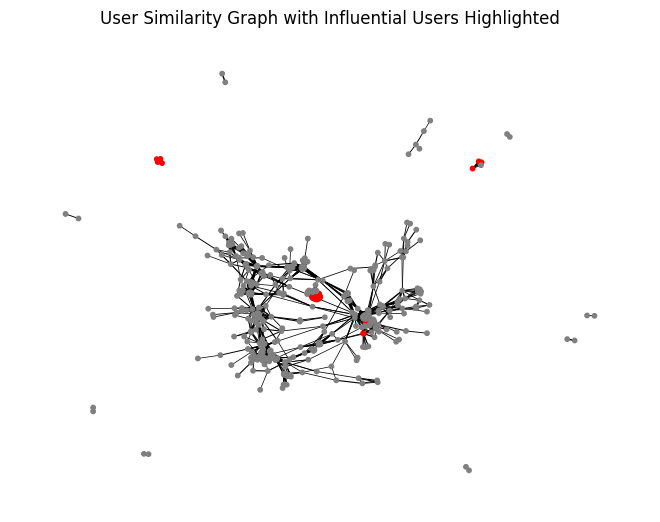

In [75]:
user = pd.read_csv('large_exps/1000 Agents/uselection_user_personas_900.csv')

for node in large_graph.nodes():
    if node in user['Name'].tolist():
        large_graph.nodes[node]['color'] = 'gray'
    else:
        large_graph.nodes[node]['color'] = 'red'

node_colors = [large_graph.nodes[node]['color'] for node in large_graph.nodes()]
nx.draw(large_graph, pos_large, node_size=10, width=edge_widths_large, node_color=node_colors)
plt.title('User Similarity Graph with Influential Users Highlighted')
plt.show()

In [76]:
# count the number of red and gray nodes
color_counts = {'red': 0, 'gray': 0}
for node in large_graph.nodes():
    color = large_graph.nodes[node]['color']
    color_counts[color] += 1
print(color_counts)

{'red': 99, 'gray': 386}


### hahstags campains study

In [102]:
# how are the campains organizade here? 
# lets see the hashtags count 
large_tweets_non_org = df_large[df_large['Type'] == 'influence']
large_tweets_non_org.head()


,TweetID,Agent Name,Iteration,Content,Type,Retweets,Likes,Replies,Recommendation,Commented On,Retweeted From,Retweet Reason,Strategy,Hashtags
0,1,SheilaNJ,0,🚨 It's time to prioritize our national securit...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,[#BorderSecurity2024]
1,2,PaulDeCristofo4,0,🇺🇸 It's time to put America first! A strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #Trump2024]"
2,3,prinzeuschen,0,🇺🇸 It's time to put America first! We need str...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #Trump2024]"
3,4,FosteSherman,0,🇺🇸💪 It's time to prioritize our national secur...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA, #ConservativeValues]"
4,5,Crypto_Sanchez,0,🚨 It's time to put America first! 🇺🇸 Strong bo...,influence,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,"[#BorderSecurity2024, #MAGA]"


In [97]:
large_tweets_non_org.info

<bound method DataFrame.info of               TweetID       Agent Name  Iteration  \
0                   1         SheilaNJ          0   
1                   2  PaulDeCristofo4          0   
2                   3     prinzeuschen          0   
3                   4     FosteSherman          0   
4                   5   Crypto_Sanchez          0   
...               ...              ...        ...   
16072           10085    Trumpster5280        300   
16073  Recommendation   BandofPatriots        300   
16074           10086   BandofPatriots        300   
16075           10087   BandofPatriots        300   
16076           10088   BandofPatriots        300   

                                                 Content       Type  Retweets  \
0      🚨 It's time to prioritize our national securit...  influence       0.0   
1      🇺🇸 It's time to put America first! A strong bo...  influence       0.0   
2      🇺🇸 It's time to put America first! We need str...  influence       0.0   
3      

In [124]:
large_hashtag_counts = Counter([hashtag for sublist in large_tweets_non_org['Hashtags'] for hashtag in sublist])
print(large_hashtag_counts.most_common())

[('#MAGA', 1141), ('#Trump2024', 1088), ('#BorderSecurity2024', 930), ('#BorderSecurityNow', 202), ('#UnityOverDivision', 141), ('#Biden2024', 129), ('#VoteForChange', 65), ('#NotMyPresident', 51), ('#SocialJusticeMatters', 14), ('#AmericaFirst', 8), ('#VoteBiden', 8), ('#BorderSecurity', 7), ('#SecureTheBorder', 6), ('#SocialJustice', 5), ('#WWG1WGA', 5), ('#SecureOurBorders', 3), ('#BIDEN2024', 3), ('#UNITYOVERDIVISION', 3), ('#MAGAisOver', 3), ('#Trump2024IsAFailure', 3), ('#ConservativeValues', 2), ('#Vote2024', 2), ('#BorderSecurity2024EMPLARY', 2), ('#NoToHate', 2), ('#QAnon', 2), ('#VoteTrump2024', 1), ('#DefendDemocracy', 1), ('#NoMoreTrump', 1), ('#VoteBlue', 1), ('#Resist', 1), ('#Election2024', 1), ('#CompassionateLeadership', 1), ('#TRUMP2024', 1), ('#BORDERSECURITYNOW', 1)]


In [125]:


large_hashtag_sum = 0
small_hashtag_sum = 0

for hs in hashtag_counts: 
    small_hashtag_sum += hashtag_counts[hs]
    print(hs,hashtag_counts[hs])
for hs in large_hashtag_counts: 
    large_hashtag_sum += large_hashtag_counts[hs]
    print(hs,large_hashtag_counts[hs])


large_hashtag_sum, small_hashtag_sum

#BorderSecurity2024 953
#MAGA 875
#MakeAmericaGreatAgain 17
#Trump2024 802
#NoToHate 1
#YesToCompassion 1
#Biden2024 118
#TrumpFailedAmerica 35
#TrumpIsLosing 1
#HealthcareForAll 1
#ImmigrationReform 2
#VoteForChange2024 4
#NotMyPresident 13
#CompassionateImmigrationReform 29
#SystemicChange 4
#PeopleOverPolitics 4
#PeopleOverProfit 3
#LeadershipMatters 37
#CompassionateReform 15
#BorderSecurity2024 930
#MAGA 1141
#Trump2024 1088
#ConservativeValues 2
#SecureOurBorders 3
#AmericaFirst 8
#SecureTheBorder 6
#VoteTrump2024 1
#VoteForChange 65
#DefendDemocracy 1
#NoMoreTrump 1
#VoteBiden 8
#UnityOverDivision 141
#VoteBlue 1
#Resist 1
#SocialJustice 5
#Vote2024 2
#SocialJusticeMatters 14
#BorderSecurityNow 202
#NotMyPresident 51
#WWG1WGA 5
#Biden2024 129
#Election2024 1
#BorderSecurity 7
#CompassionateLeadership 1
#BorderSecurity2024EMPLARY 2
#BIDEN2024 3
#UNITYOVERDIVISION 3
#TRUMP2024 1
#BORDERSECURITYNOW 1
#NoToHate 2
#MAGAisOver 3
#Trump2024IsAFailure 3
#QAnon 2


(3834, 2915)

In [146]:
hashtag_ct_per_iteration = {}
hashtags_list =  set(hashtag for hashtags in large_tweets_non_org['Hashtags'] for hashtag in hashtags)

iterations = sorted(df_large['Iteration'].unique())

# Initialize dictionary
for hashtag in hashtags_list:
    hashtag_ct_per_iteration[hashtag] = []

# Count hashtags per iteration
for iteration in iterations:
    df_iteration = df_large[df_large['Iteration'] == iteration]

    hashtags_list_it =  set(hashtag for hashtags in df_iteration['Hashtags'] for hashtag in hashtags)

    hashtag_counts = Counter(hashtags_list_it)

    for hashtag in hashtags_list: 
        hashtag_ct_per_iteration[hashtag].append(hashtag_counts.get(hashtag, 0))
        if len(hashtag_ct_per_iteration[hashtag]) > 1: hashtag_ct_per_iteration[hashtag][-1] += hashtag_ct_per_iteration[hashtag][-2]

/tmp/ipykernel_277/3904910616.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


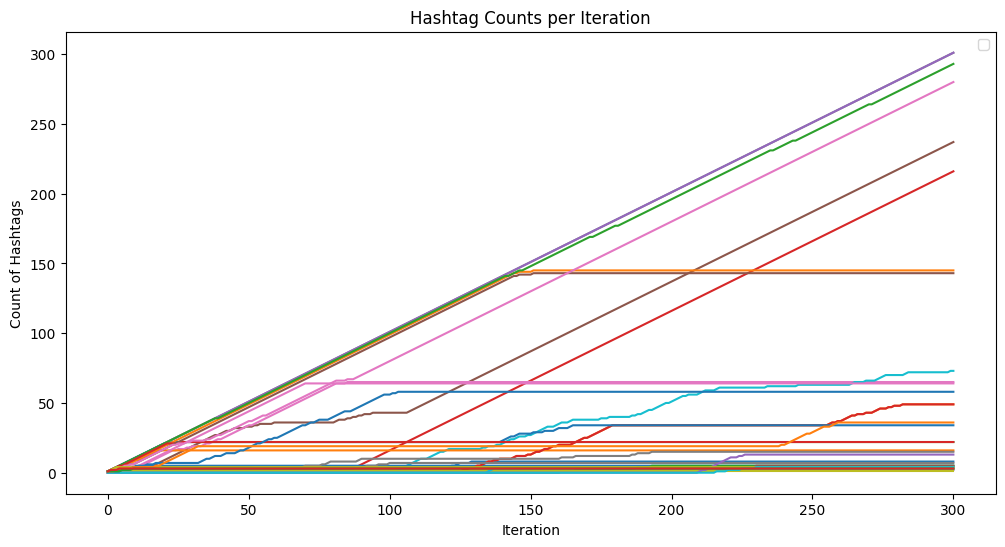

In [148]:
## what I am trying to do 
## see how the hashtags behave over the iterations
plt.figure(figsize=(12, 6))

for hashtag, counts in hashtag_ct_per_iteration.items():
    plt.plot(iterations, counts)

plt.xlabel('Iteration')
plt.ylabel('Count of Hashtags')
plt.title('Hashtag Counts per Iteration')
plt.legend()
plt.show()